# Phase 3 — Local Baseline Modeling
Naive baseline vs XGBoost, evaluated with MAE/MAPE, broken down by season and hour.
No AWS cost — this validates the modeling approach before we pay for SageMaker training.

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

DATA_DIR = "../data/processed"

In [9]:
# ---- Load splits ----
train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val = pd.read_parquet(f"{DATA_DIR}/val.parquet")
test = pd.read_parquet(f"{DATA_DIR}/test.parquet")

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
train.head()

Train: (131299, 18), Val: (8759, 18), Test: (5136, 18)


,Datetime,PJME_MW,hour,dayofweek,month,quarter,is_weekend,is_holiday,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,lag_24h,lag_168h,rolling_mean_168h,rolling_std_168h
0,2002-01-08 01:00:00,29445.0,1,1,1,1,0,0,0.258819,0.965926,0.5,0.866025,0.781831,0.62349,26862.0,30393.0,32519.511905,3857.950565
1,2002-01-08 02:00:00,28670.0,2,1,1,1,0,0,0.500000,0.866025,0.5,0.866025,0.781831,0.62349,25976.0,29265.0,32513.869048,3861.770954
2,2002-01-08 03:00:00,28375.0,3,1,1,1,0,0,0.707107,0.707107,0.5,0.866025,0.781831,0.62349,25641.0,28357.0,32510.327381,3865.039821
3,2002-01-08 04:00:00,28542.0,4,1,1,1,0,0,0.866025,0.500000,0.5,0.866025,0.781831,0.62349,25666.0,27899.0,32510.434524,3864.924245
4,2002-01-08 05:00:00,29261.0,5,1,1,1,0,0,0.965926,0.258819,0.5,0.866025,0.781831,0.62349,26328.0,28057.0,32514.261905,3860.646270


In [10]:
# ---- Feature / target split ----
FEATURES = [
    "hour", "dayofweek", "month", "quarter", "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos",
    "lag_24h", "lag_168h", "rolling_mean_168h", "rolling_std_168h",
]
TARGET = "PJME_MW"  # Athena lowercased the column name — confirm this matches your Parquet schema

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

## 1. Naive baseline
"Same hour, one week ago" — this is the floor any real model must beat.
If XGBoost can't beat this, the extra complexity isn't earning its keep.

In [11]:
naive_pred_val = val["lag_168h"]

naive_mae = mean_absolute_error(y_val, naive_pred_val)
naive_mape = mean_absolute_percentage_error(y_val, naive_pred_val) * 100

print(f"Naive baseline (lag_168h) — Val MAE: {naive_mae:.1f} MW, MAPE: {naive_mape:.2f}%")

Naive baseline (lag_168h) — Val MAE: 3446.6 MW, MAPE: 10.92%


## 2. XGBoost model

In [12]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

[0]	validation_0-mae:4776.70179
[50]	validation_0-mae:1901.37831
[100]	validation_0-mae:1794.29921
[150]	validation_0-mae:1785.03162
[200]	validation_0-mae:1778.30463
[236]	validation_0-mae:1778.21612


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [13]:
xgb_pred_val = model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_pred_val)
xgb_mape = mean_absolute_percentage_error(y_val, xgb_pred_val) * 100

print(f"XGBoost — Val MAE: {xgb_mae:.1f} MW, MAPE: {xgb_mape:.2f}%")
print(f"\nImprovement over naive baseline: {naive_mae - xgb_mae:.1f} MW "
      f"({(1 - xgb_mae/naive_mae) * 100:.1f}% reduction in MAE)")

XGBoost — Val MAE: 1777.3 MW, MAPE: 5.71%

Improvement over naive baseline: 1669.3 MW (48.4% reduction in MAE)


## 3. Error breakdown by season and hour-of-day
Aggregate MAE hides where the model actually struggles. Break it down.

In [14]:
val_eval = val.copy()
val_eval["y_true"] = y_val
val_eval["y_pred_xgb"] = xgb_pred_val
val_eval["y_pred_naive"] = naive_pred_val
val_eval["abs_err_xgb"] = (val_eval["y_true"] - val_eval["y_pred_xgb"]).abs()
val_eval["abs_err_naive"] = (val_eval["y_true"] - val_eval["y_pred_naive"]).abs()

# Season from month
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

val_eval["season"] = val_eval["month"].apply(month_to_season)

In [15]:
print("=== MAE by season ===")
season_mae = val_eval.groupby("season")[["abs_err_naive", "abs_err_xgb"]].mean()
print(season_mae)

print("\n=== MAE by hour of day ===")
hour_mae = val_eval.groupby("hour")[["abs_err_naive", "abs_err_xgb"]].mean()
print(hour_mae)

=== MAE by season ===
        abs_err_naive  abs_err_xgb
season                            
Fall      3082.396978  1467.945574
Spring    2632.246488  1537.446246
Summer    4524.183877  2247.186904
Winter    3545.406944  1854.844719

=== MAE by hour of day ===
      abs_err_naive  abs_err_xgb
hour                            
0       3092.575342  1570.419531
1       2936.495890  1533.492380
2       2822.309589  1473.090213
3       2753.068681  1451.101503
4       2696.824658  1443.768611
5       2688.112329  1443.421399
6       2735.356164  1503.580806
7       2828.531507  1592.437923
8       2881.534247  1599.402451
9       2911.079452  1594.347576
10      3056.304110  1653.469975
11      3308.961644  1783.181742
12      3591.082192  1921.697902
13      3864.465753  2031.112463
14      4093.476712  2084.729067
15      4252.542466  2147.171147
16      4376.238356  2164.081261
17      4450.569863  2174.816556
18      4454.983562  2170.492717
19      4250.843836  2051.140823
20      4009.6

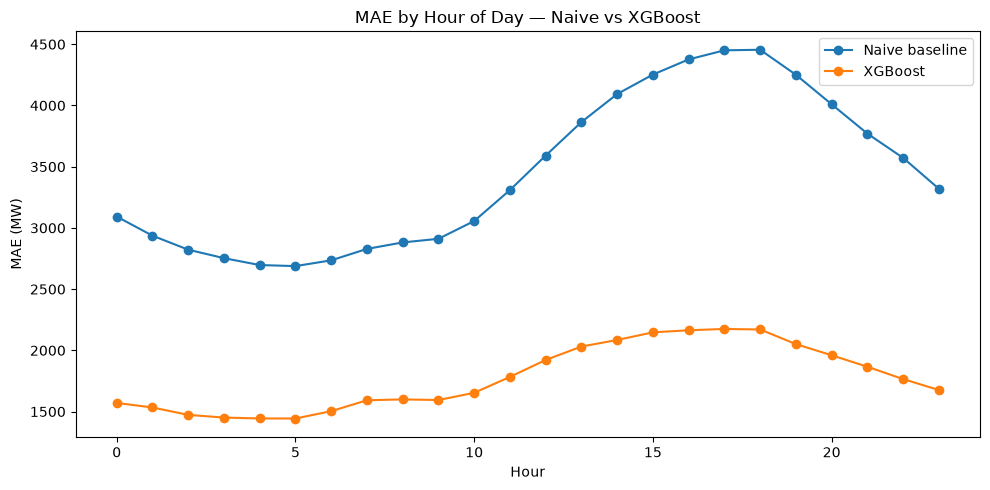

In [17]:
# ---- Plot: error by hour of day ----
fig, ax = plt.subplots(figsize=(10, 5))
hour_mae.plot(ax=ax, marker="o")
ax.set_title("MAE by Hour of Day — Naive vs XGBoost")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE (MW)")
ax.legend(["Naive baseline", "XGBoost"])
plt.tight_layout()
plt.savefig("../docs/mae_by_hour.png", dpi=150)
plt.show()

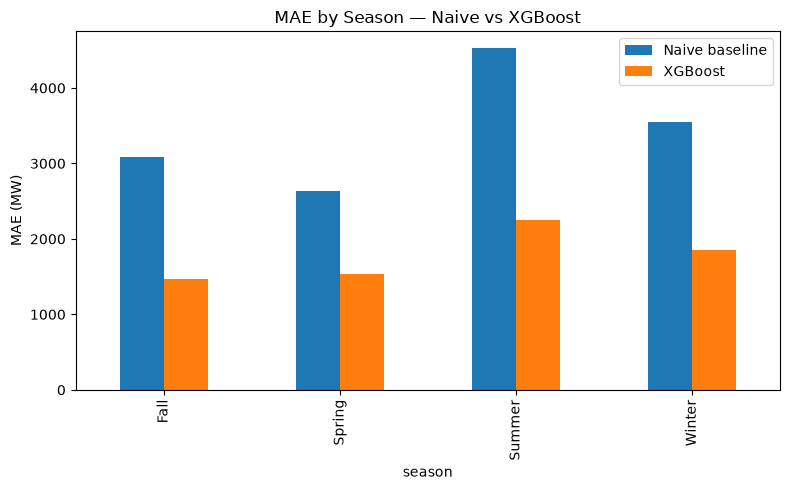

In [19]:
# ---- Plot: error by season ----
fig, ax = plt.subplots(figsize=(8, 5))
season_mae.plot(kind="bar", ax=ax)
ax.set_title("MAE by Season — Naive vs XGBoost")
ax.set_ylabel("MAE (MW)")
ax.legend(["Naive baseline", "XGBoost"])
plt.tight_layout()
plt.savefig("../docs/mae_by_season.png", dpi=150)
plt.show()

## 4. Feature importance
Which features is the model actually leaning on? Good talking point for interviews.

lag_24h              0.641535
lag_168h             0.149759
dayofweek            0.030830
is_weekend           0.028094
dow_sin              0.026930
hour                 0.018574
month_cos            0.018407
hour_cos             0.017821
dow_cos              0.013274
is_holiday           0.012063
hour_sin             0.011664
rolling_std_168h     0.007560
quarter              0.006281
month_sin            0.006064
month                0.005752
rolling_mean_168h    0.005392
dtype: float32


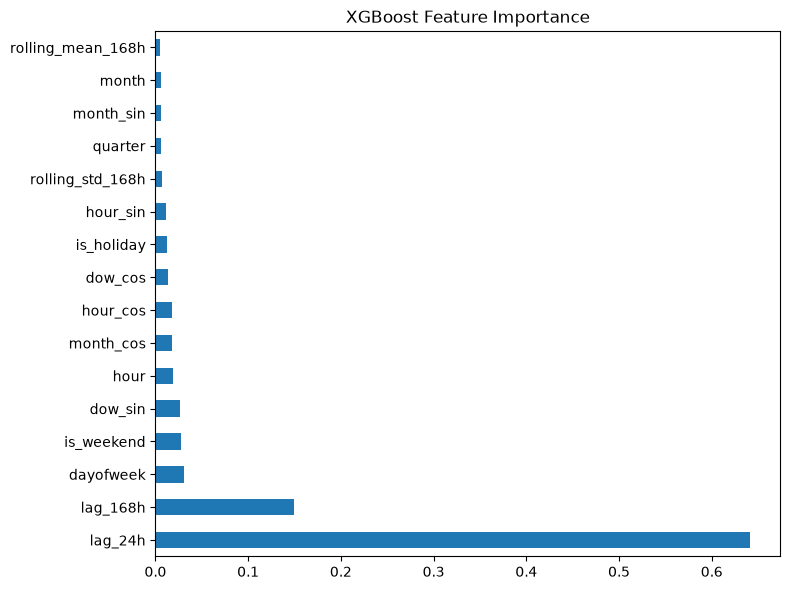

In [21]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind="barh", ax=ax)
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig("../docs/feature_importance.png", dpi=150)
plt.show()

## Next: if these numbers look good, we port this exact training logic into a
SageMaker training job (Phase 4) — same features, same model, just running on AWS
infrastructure and reading from S3 directly instead of local Parquet files.